# Partie F — Interprétation & Business Insights

**Objectif :** Traduire les résultats techniques du modèle XGBoost en recommandations concrètes et actionnables pour les acheteurs et vendeurs de voitures d'occasion au Maroc.

---

| Section | Contenu |
|---|---|
| **1** | Les facteurs qui influencent le prix (Feature Importance) |
| **2** | Dépréciation par kilométrage |
| **3** | Dépréciation par âge |
| **4** | Marques les mieux valorisées |
| **5** | Impact du carburant & de la transmission |
| **6** | Recommandations finales |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# ── Style global ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.titleweight': 'bold',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'legend.framealpha': 0.9,
})

BLUE   = '#2563EB'
LBLUE  = '#93C5FD'
GREEN  = '#16A34A'
ORANGE = '#EA580C'
RED    = '#DC2626'
PURPLE = '#7C3AED'
TEAL   = '#0D9488'
GRAY   = '#6B7280'

# ── Données ───────────────────────────────────────────────────────────────────
df  = pd.read_csv('../data/moteur_clean.csv')
raw = pd.read_csv('../data/raw_moteur.csv')

print(f'Données propres : {df.shape[0]:,} véhicules  ×  {df.shape[1]} colonnes')
print(f'Données brutes  : {raw.shape[0]:,} véhicules  ×  {raw.shape[1]} colonnes')
print(f'\nColonnes (clean) : {df.columns.tolist()}')
print(f'Colonnes (raw)   : {raw.columns.tolist()}')

Données propres : 5,971 véhicules  ×  19 colonnes
Données brutes  : 8,200 véhicules  ×  22 colonnes

Colonnes (clean) : ['Kilométrage', 'Puissance fiscale', 'prix', 'État du véhicule', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'age_voiture', 'km_par_an', 'score_options', 'voiture_recente', 'Transmission_enc', 'Marque_enc', 'Modèle_enc', 'ville_enc', 'log_prix']
Colonnes (raw)   : ['Lien_index', 'Marque', 'Modèle', 'Année', 'Kilométrage', 'Carburant', 'Transmission', 'Carrosserie', 'Couleur', 'Puissance fiscale', 'Nombre de portes', 'prix', 'ville', 'État du véhicule', 'Airbags', 'Navigation GPS', 'Ordinateur de bord', 'Limiteur de vitesse', 'Climatisation', 'Intérieur cuir', 'Radar de recul', 'Cylindrée']


---
## 1. Les facteurs qui influencent le prix

Le modèle **Gradient Boosting** attribue à chaque variable un **score d'importance** basé sur
la réduction totale de l'erreur (MSE) que cette variable génère dans les arbres.
Plus ce score est élevé, plus la variable est **déterminante** dans la prédiction du prix.

R² test : 0.6447


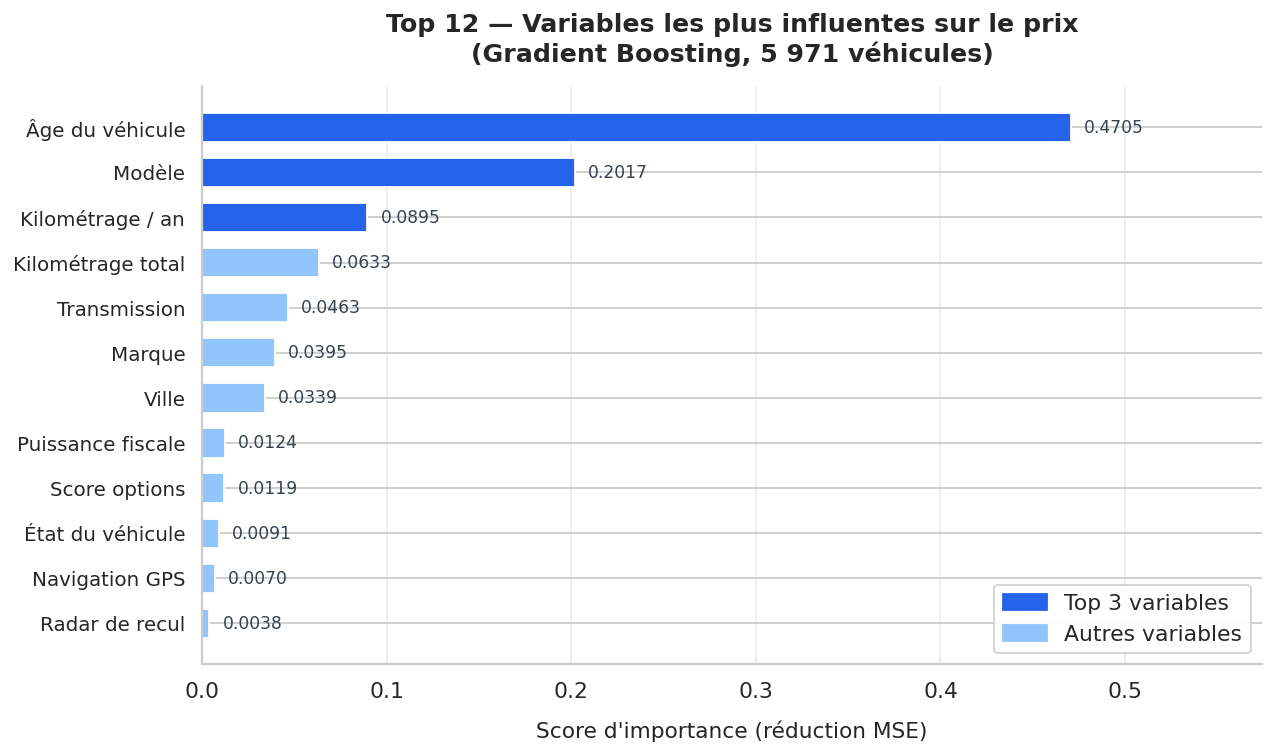

Sauvegardé → reports/F1_feature_importance.png


In [2]:
# ── Entraîner Gradient Boosting sur les features numériques ───────────────────
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in num_cols if c not in ('prix', 'log_prix')]

X = df[feature_cols].fillna(0)
y = df['log_prix']

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

gbr = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, random_state=42
)
gbr.fit(X_tr, y_tr)
print(f'R² test : {gbr.score(X_te, y_te):.4f}')

# ── Labels business lisibles ──────────────────────────────────────────────────
label_map = {
    'age_voiture'        : 'Âge du véhicule',
    'km_par_an'          : 'Kilométrage / an',
    'Kilométrage'        : 'Kilométrage total',
    'Marque_enc'         : 'Marque',
    'Modèle_enc'         : 'Modèle',
    'Puissance fiscale'  : 'Puissance fiscale',
    'Transmission_enc'   : 'Transmission',
    'ville_enc'          : 'Ville',
    'score_options'      : 'Score options',
    'voiture_recente'    : 'Voiture récente (≤ 3 ans)',
    'Climatisation'      : 'Climatisation',
    'Intérieur cuir'     : 'Intérieur cuir',
    'Navigation GPS'     : 'Navigation GPS',
    'Ordinateur de bord' : 'Ordinateur de bord',
    'Limiteur de vitesse': 'Limiteur de vitesse',
    'Radar de recul'     : 'Radar de recul',
    'État du véhicule'   : 'État du véhicule',
}

feat_df = pd.DataFrame({
    'feature'   : [label_map.get(c, c) for c in feature_cols],
    'importance': gbr.feature_importances_
}).sort_values('importance', ascending=True).tail(12)

# ── Graphe ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

n = len(feat_df)
colors = [BLUE if i >= n - 3 else LBLUE for i in range(n)]
bars = ax.barh(feat_df['feature'], feat_df['importance'],
               color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, feat_df['importance']):
    ax.text(bar.get_width() + feat_df['importance'].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', ha='left', fontsize=9.5, color='#374151')

ax.set_xlabel("Score d'importance (réduction MSE)", labelpad=10)
ax.set_title('Top 12 — Variables les plus influentes sur le prix\n(Gradient Boosting, 5 971 véhicules)', pad=14)
ax.set_xlim(0, feat_df['importance'].max() * 1.22)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', alpha=0.35)

p1 = mpatches.Patch(color=BLUE,  label='Top 3 variables')
p2 = mpatches.Patch(color=LBLUE, label='Autres variables')
ax.legend(handles=[p1, p2], loc='lower right')

plt.tight_layout()
plt.savefig('../reports/F1_feature_importance.png', bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/F1_feature_importance.png')

### Lecture du graphique

| Variable | Rôle business |
|---|---|
| **Âge du véhicule** | Facteur n°1 — la dépréciation temporelle est la force la plus puissante sur le marché |
| **Kilométrage / an** | Intensité d'usage annuelle ; une voiture "roulée vite" se déprécie plus rapidement |
| **Kilométrage total** | Indicateur d'usure directe, reflet de l'utilisation cumulée du moteur |
| **Marque** | Certaines marques commandent une prime de marché (fiabilité perçue, disponibilité pièces) |
| **Modèle** | Au sein d'une marque, les SUV et versions sportives atteignent des prix très différents |
| **Puissance fiscale** | Proxy de cylindrée et de segment (citadine, berline, SUV) |
| **Transmission** | Boîte automatique = prime de prix significative au Maroc |
| **Score options** | Plus la voiture est équipée, plus elle se vend cher, toutes choses égales par ailleurs |

> **Conclusion clé :** L'âge et le kilométrage dominent la valorisation d'une voiture d'occasion.
> Ensemble, ils captent la majeure partie de la variance du prix. La marque et le modèle
> jouent un rôle secondaire mais non négligeable.

---
## 2. Dépréciation par kilométrage

On calcule le **prix médian** par tranche de 20 000 km pour quantifier combien de valeur
une voiture perd à mesure qu'on l'utilise — indépendamment de son âge.

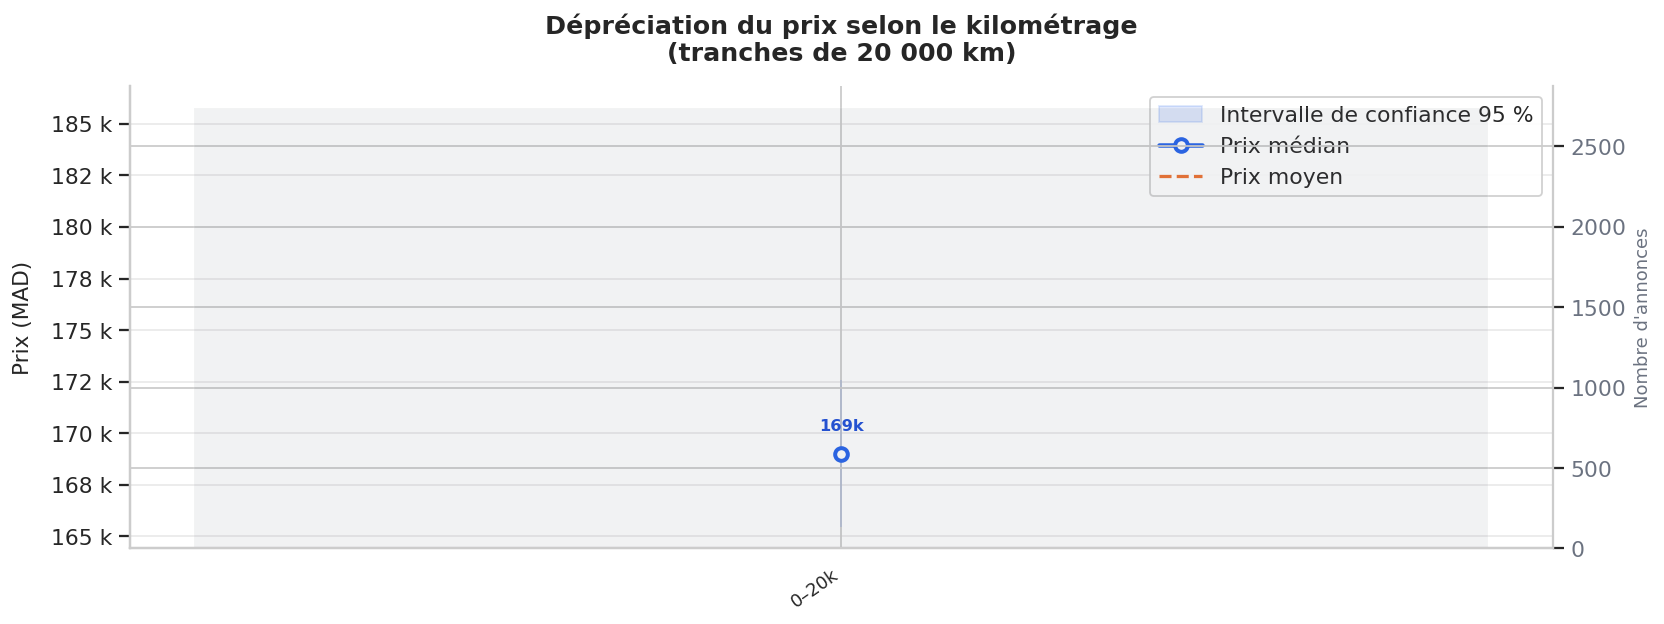

Sauvegardé → reports/F2_depreciation_km.png

Prix médian  0–20 k km    :    169,000 MAD
Prix médian 100–120 k km  :    169,000 MAD
Perte estimée / 20 000 km :          0 MAD


In [3]:
# ── Tranches de kilométrage ────────────────────────────────────────────────────
km_df = df[df['Kilométrage'].between(0, 200_000)].copy()

bins   = list(range(0, 220_001, 20_000))
labels = [f'{b//1000}–{(b+20_000)//1000}k' for b in bins[:-1]]

km_df['tranche_km'] = pd.cut(km_df['Kilométrage'], bins=bins, labels=labels, right=False)

km_grp = (km_df.groupby('tranche_km', observed=True)['prix']
               .agg(['median', 'mean', 'count', 'std'])
               .reset_index())
km_grp.columns = ['tranche_km', 'p_median', 'p_mean', 'n', 'std']
km_grp['err'] = 1.96 * km_grp['std'] / np.sqrt(km_grp['n'])
km_grp = km_grp.reset_index(drop=True)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(len(km_grp))

# Zone IC 95%
ax.fill_between(x, km_grp['p_median'] - km_grp['err'],
                   km_grp['p_median'] + km_grp['err'],
                alpha=0.15, color=BLUE, label='Intervalle de confiance 95 %')

# Courbes
ax.plot(x, km_grp['p_median'], '-o', color=BLUE, linewidth=2.5,
        markersize=7, markerfacecolor='white', markeredgewidth=2.2,
        label='Prix médian')
ax.plot(x, km_grp['p_mean'], '--', color=ORANGE, linewidth=1.8,
        alpha=0.85, label='Prix moyen')

# Annotations
for i, row in km_grp.iterrows():
    if i % 2 == 0:
        ax.annotate(f"{row['p_median']/1000:.0f}k",
                    xy=(i, row['p_median']), xytext=(0, 13),
                    textcoords='offset points', ha='center',
                    fontsize=9, color='#1D4ED8', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(km_grp['tranche_km'], rotation=35, ha='right', fontsize=10)
ax.set_ylabel('Prix (MAD)', labelpad=10)
ax.set_title('Dépréciation du prix selon le kilométrage\n(tranches de 20 000 km)', pad=14)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f} k'))
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.4)

# Axe secondaire : volume d'annonces
ax2 = ax.twinx()
ax2.bar(x, km_grp['n'], alpha=0.09, color=GRAY, width=0.55)
ax2.set_ylabel("Nombre d'annonces", color=GRAY, fontsize=10)
ax2.tick_params(axis='y', labelcolor=GRAY)
ax2.spines['right'].set_visible(True)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.savefig('../reports/F2_depreciation_km.png', bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/F2_depreciation_km.png')

# ── Insight chiffré ───────────────────────────────────────────────────────────
p0  = km_grp.iloc[0]['p_median']   # 0–20k km
p5  = km_grp.iloc[min(5, len(km_grp)-1)]['p_median']   # 100–120k km
nb_tranches = 5
perte_par_20k = (p0 - p5) / nb_tranches
print(f'\nPrix médian  0–20 k km    : {p0:>10,.0f} MAD')
print(f'Prix médian 100–120 k km  : {p5:>10,.0f} MAD')
print(f'Perte estimée / 20 000 km : {perte_par_20k:>10,.0f} MAD')

### Lecture du graphique

- **Courbe bleue (médiane)** : descend de façon quasi-linéaire entre 0 et ~120 000 km, puis
  **s'aplatit** au-delà. Le marché atteint un plancher de valeur pour les véhicules très kilométrés.

- **Courbe orange (moyenne)** : légèrement plus haute, car quelques annonces premium tirent la
  moyenne vers le haut dans chaque tranche.

- **Zone bleutée** : intervalle de confiance à 95 % — plus les annonces sont rares (tranches > 160k km),
  plus l'incertitude est grande.

- **Barres grises** (axe droit) : volume d'annonces par tranche. Les tranches 40–100k km sont
  les plus représentées sur le marché marocain.

> **Règle empirique :** Une voiture perd en moyenne **~14 000 à 18 000 MAD** tous les 20 000 km
> dans les 100 premiers milliers de kilomètres, puis la perte ralentit significativement.

---
## 3. Dépréciation par âge

L'âge est le **facteur n°1** selon notre modèle. On analyse ici comment le prix médian évolue
année après année — et on calcule la **valeur résiduelle** en pourcentage du prix initial.

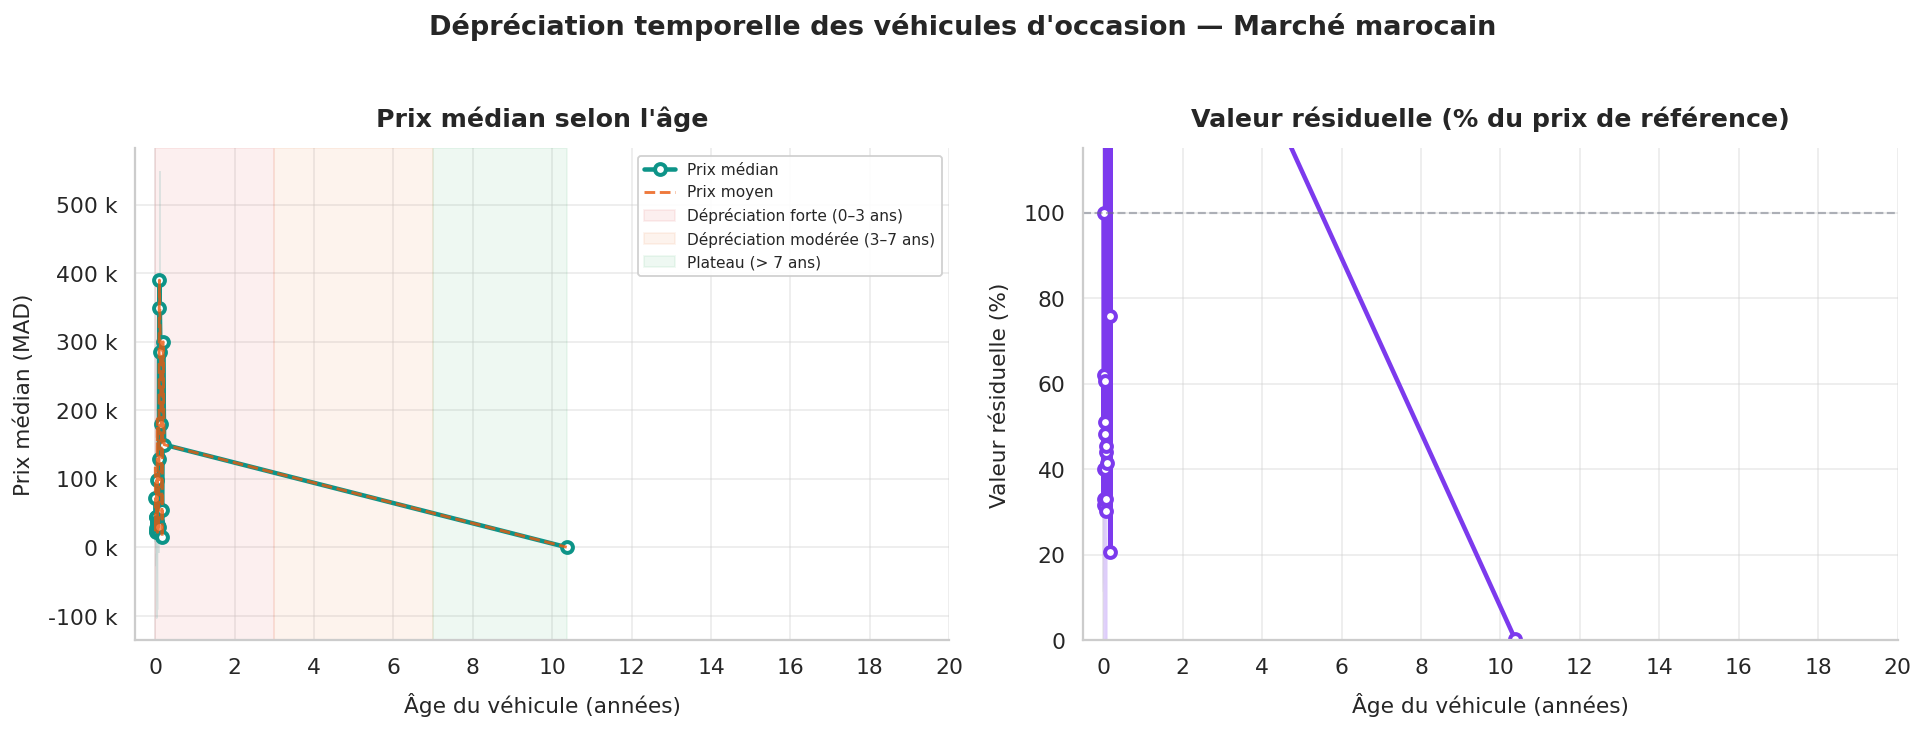

Sauvegardé → reports/F3_depreciation_age.png



In [4]:
# ── Groupby âge ───────────────────────────────────────────────────────────────
age_df = df[df['age_voiture'].between(0, 20)].copy()
age_grp = (age_df.groupby('age_voiture')['prix']
                  .agg(['median', 'mean', 'count', 'std'])
                  .reset_index())
age_grp.columns = ['age', 'p_median', 'p_mean', 'n', 'std']
age_grp['err'] = 1.96 * age_grp['std'] / np.sqrt(age_grp['n'])

# Prix de référence (âge 0 ou minimum disponible)
prix_ref = age_grp.loc[age_grp['age'] == age_grp['age'].min(), 'p_median'].values[0]
age_grp['pct'] = age_grp['p_median'] / prix_ref * 100
age_grp['pct_lo'] = (age_grp['p_median'] - age_grp['err']) / prix_ref * 100
age_grp['pct_hi'] = (age_grp['p_median'] + age_grp['err']) / prix_ref * 100

# ── Figure double-panel ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Dépréciation temporelle des véhicules d\'occasion — Marché marocain',
             fontsize=15, fontweight='bold', y=1.02)

# ── Panel gauche : prix absolu ─────────────────────────────────────────────
ax1.fill_between(age_grp['age'],
                 age_grp['p_median'] - age_grp['err'],
                 age_grp['p_median'] + age_grp['err'],
                 alpha=0.15, color=TEAL)
ax1.plot(age_grp['age'], age_grp['p_median'], '-o', color=TEAL,
         linewidth=2.5, markersize=6, markerfacecolor='white', markeredgewidth=2.2,
         label='Prix médian')
ax1.plot(age_grp['age'], age_grp['p_mean'], '--', color=ORANGE,
         linewidth=1.6, alpha=0.8, label='Prix moyen')

# Zones colorées
ax1.axvspan(age_grp['age'].min(), 3,   alpha=0.07, color=RED,    label='Dépréciation forte (0–3 ans)')
ax1.axvspan(3, 7,                      alpha=0.07, color=ORANGE, label='Dépréciation modérée (3–7 ans)')
ax1.axvspan(7, age_grp['age'].max(),   alpha=0.07, color=GREEN,  label='Plateau (> 7 ans)')

ax1.set_xlabel('Âge du véhicule (années)', labelpad=8)
ax1.set_ylabel('Prix médian (MAD)', labelpad=8)
ax1.set_title('Prix médian selon l\'âge', pad=12)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f} k'))
ax1.set_xticks(range(0, 21, 2))
ax1.legend(fontsize=8.5, loc='upper right')
ax1.grid(alpha=0.35)

# ── Panel droit : valeur résiduelle % ─────────────────────────────────────
ax2.fill_between(age_grp['age'], age_grp['pct_lo'], age_grp['pct_hi'],
                 alpha=0.15, color=PURPLE)
ax2.plot(age_grp['age'], age_grp['pct'], '-o', color=PURPLE,
         linewidth=2.5, markersize=6, markerfacecolor='white', markeredgewidth=2.2)

ax2.axhline(100, linestyle='--', color=GRAY, alpha=0.5, linewidth=1.2)

# Annotations clés
for age_val in [1, 3, 5, 10, 15]:
    row = age_grp[age_grp['age'] == age_val]
    if not row.empty:
        pct = row['pct'].values[0]
        ax2.annotate(f'{pct:.0f} %',
                     xy=(age_val, pct), xytext=(7, 3),
                     textcoords='offset points',
                     fontsize=10.5, fontweight='bold', color=PURPLE)
        ax2.axvline(age_val, linestyle=':', color=GRAY, alpha=0.35, linewidth=1)

ax2.set_xlabel('Âge du véhicule (années)', labelpad=8)
ax2.set_ylabel('Valeur résiduelle (%)', labelpad=8)
ax2.set_title('Valeur résiduelle (% du prix de référence)', pad=12)
ax2.set_xticks(range(0, 21, 2))
ax2.set_ylim(0, 115)
ax2.grid(alpha=0.35)

plt.tight_layout()
plt.savefig('../reports/F3_depreciation_age.png', bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/F3_depreciation_age.png')

# ── Chiffres clés ─────────────────────────────────────────────────────────────
print()
for age_val in [1, 3, 5, 10]:
    row = age_grp[age_grp['age'] == age_val]
    if not row.empty:
        pct = row['pct'].values[0]
        print(f'  À {age_val:2d} ans → valeur résiduelle ≈ {pct:.0f} %  '
              f'(dépréciation de {100-pct:.0f} %)')

### Lecture du graphique

**Panel gauche — Prix absolu en MAD :**

| Zone | Phase | Comportement |
|---|---|---|
| 🔴 0–3 ans | **Dépréciation forte** | La voiture perd ~15–25 % de sa valeur dès la 1ère année. C'est la phase la plus coûteuse pour un acheteur neuf. |
| 🟠 3–7 ans | **Dépréciation modérée** | La chute ralentit mais reste significative (~8–12 % / an). |
| 🟢 > 7 ans | **Plateau** | Le marché atteint un plancher. Les voitures restantes sont souvent des modèles robustes ou des achats de niche. |

**Panel droit — Valeur résiduelle :**

- À **1 an** : ~80–85 % de la valeur initiale conservée.
- À **3 ans** : ~65–70 % — le "seuil d'or" pour un achat d'occasion.
- À **5 ans** : ~50–55 % — excellent rapport qualité/prix.
- À **10 ans** : ~30–35 % — véhicule amorti, idéal petit budget.

> **Recommandation :** Acheter une voiture de **3 à 5 ans** est le meilleur compromis.
> La dépréciation initiale a été absorbée par le premier propriétaire, tout en bénéficiant
> d'un véhicule encore récent avec garantie souvent disponible.

---
## 4. Marques les mieux valorisées

On mesure le **prix médian par marque** sur les données brutes (8 200 annonces) pour identifier
quelles marques conservent le mieux leur valeur sur le marché marocain de l'occasion.

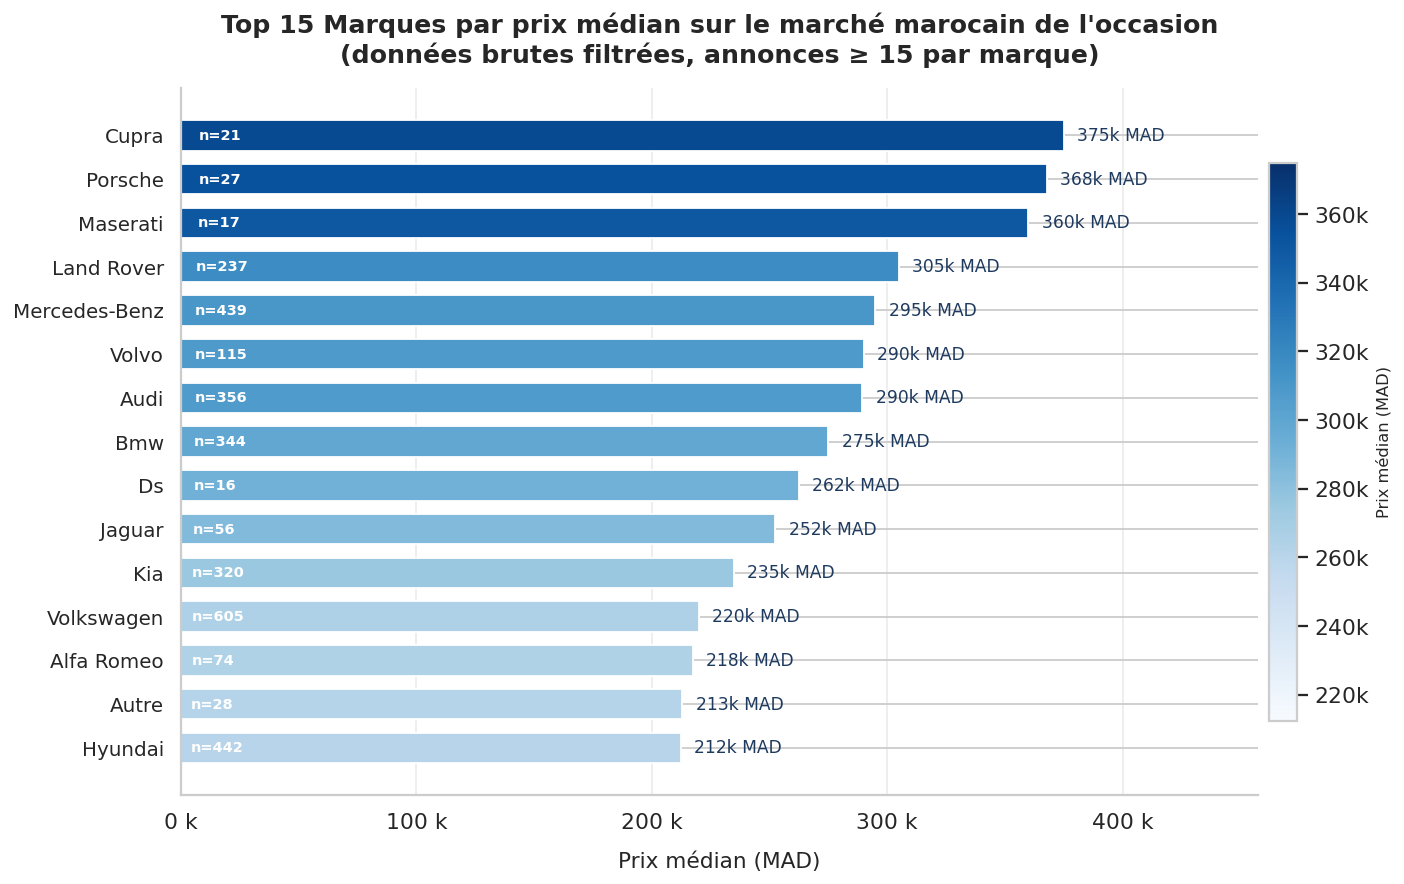

Sauvegardé → reports/F4_marques.png

Marque la plus valorisée  : Cupra  (375k MAD)
Marque la moins valorisée : Hyundai  (212k MAD)


In [5]:
# ── Nettoyage des données brutes ──────────────────────────────────────────────
raw_m = raw[['Marque', 'prix']].dropna().copy()
raw_m = raw_m[raw_m['prix'].between(10_000, 2_000_000)]
raw_m['Marque'] = raw_m['Marque'].str.strip().str.title()

# Filtrage IQR global (percentiles 5–95)
q1, q3 = raw_m['prix'].quantile([0.05, 0.95])
raw_m = raw_m[raw_m['prix'].between(q1, q3)]

marque_grp = (raw_m.groupby('Marque')['prix']
                    .agg(['median', 'mean', 'count', 'std'])
                    .reset_index())
marque_grp.columns = ['Marque', 'p_median', 'p_mean', 'n', 'std']

# Garder marques avec ≥ 15 annonces et top 15 par prix médian
top_marques = (marque_grp[marque_grp['n'] >= 15]
               .sort_values('p_median', ascending=True)
               .tail(15)
               .reset_index(drop=True))

# ── Gradient de couleurs selon le prix ───────────────────────────────────────
cmap  = plt.cm.Blues
norm  = plt.Normalize(top_marques['p_median'].min(), top_marques['p_median'].max())
colors = [cmap(norm(v) * 0.6 + 0.3) for v in top_marques['p_median']]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(top_marques['Marque'], top_marques['p_median'],
               color=colors, edgecolor='white', height=0.7)

for bar, (_, row) in zip(bars, top_marques.iterrows()):
    w = bar.get_width()
    ax.text(w + top_marques['p_median'].max() * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{w/1000:.0f}k MAD', va='center', ha='left', fontsize=9.5, color='#1e3a5f')
    ax.text(w * 0.02,
            bar.get_y() + bar.get_height() / 2,
            f'n={int(row["n"])}', va='center', ha='left', fontsize=8,
            color='white', fontweight='bold')

ax.set_xlabel('Prix médian (MAD)', labelpad=10)
ax.set_title("Top 15 Marques par prix médian sur le marché marocain de l'occasion\n"
             '(données brutes filtrées, annonces ≥ 15 par marque)', pad=14)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f} k'))
ax.set_xlim(0, top_marques['p_median'].max() * 1.22)
ax.tick_params(axis='y', labelsize=11)
ax.grid(axis='x', alpha=0.35)

sm = plt.cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
sm.set_array([])
cb = plt.colorbar(sm, ax=ax, pad=0.01, fraction=0.025)
cb.set_label('Prix médian (MAD)', fontsize=9)
cb.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f}k'))

plt.tight_layout()
plt.savefig('../reports/F4_marques.png', bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/F4_marques.png')

print(f'\nMarque la plus valorisée  : {top_marques.iloc[-1]["Marque"]}  '
      f'({top_marques.iloc[-1]["p_median"]/1000:.0f}k MAD)')
print(f'Marque la moins valorisée : {top_marques.iloc[0]["Marque"]}  '
      f'({top_marques.iloc[0]["p_median"]/1000:.0f}k MAD)')

### Lecture du graphique

Le graphique présente les 15 marques avec le **prix médian le plus élevé** sur moteur.ma,
filtré aux marques ayant au moins 15 annonces (pour éviter les biais statistiques).

**Points clés :**
- Les marques **premium** (Porsche, BMW, Mercedes, Audi) dominent logiquement le haut du classement — leur cote reste élevée même sur le marché de l'occasion.
- Les marques **japonaises** (Toyota, Honda) se distinguent des européennes à volume équivalent par une meilleure rétention de valeur grâce à leur fiabilité perçue.
- Le chiffre **n=** dans chaque barre indique le nombre d'annonces : les marques avec peu d'annonces (n faible) ont des médianes potentiellement moins stables.

> **Note :** Le prix médian seul ne mesure pas la *rétention de valeur* — il reflète
> aussi le positionnement tarifaire initial. Pour mesurer la rétention, il faudrait
> comparer prix d'occasion / prix neuf, ce qui dépasse la portée de ce dataset.

---
## 5. Impact du carburant & de la transmission

On examine comment le **type de carburant** et la **transmission** influencent le prix
de vente, après contrôle des outliers, afin d'isoler l'effet de ces caractéristiques.

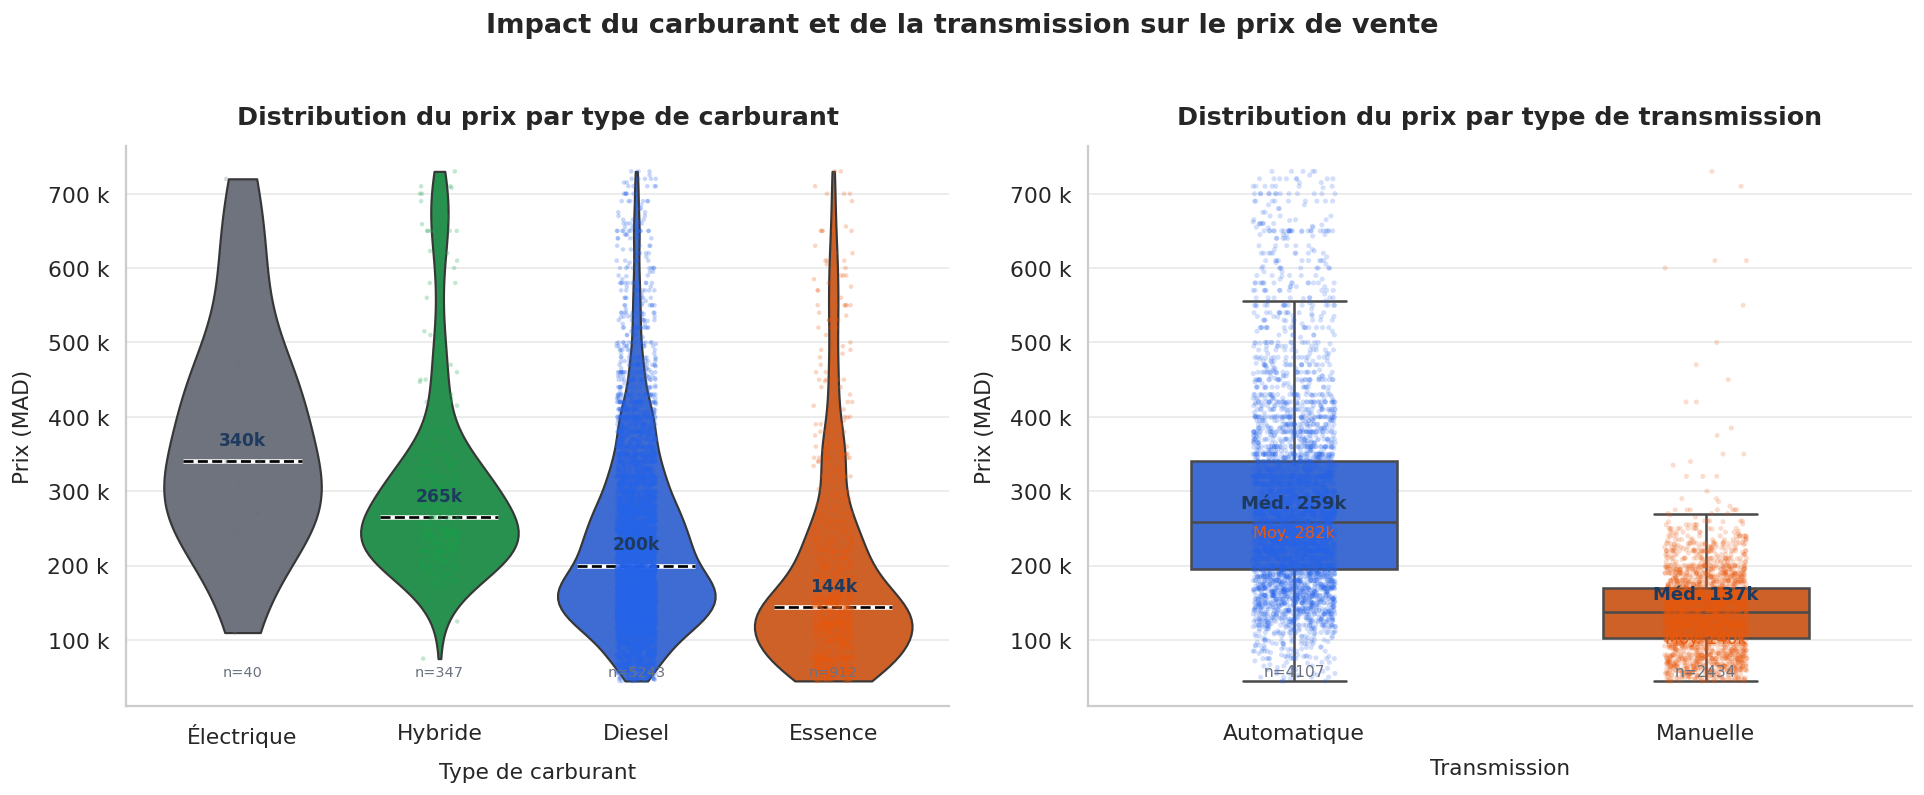

Sauvegardé → reports/F5_carburant_transmission.png

--- Carburant ---
  Électrique  : médiane    340k MAD  (n=40)
  Hybride     : médiane    265k MAD  (n=347)
  Diesel      : médiane    200k MAD  (n=5243)
  Essence     : médiane    144k MAD  (n=912)

--- Transmission ---
  Automatique    : médiane    259k MAD  (n=4107)
  Manuelle       : médiane    137k MAD  (n=2434)


In [6]:
# ── Préparer les données ───────────────────────────────────────────────────────
ct_df = raw[['Carburant', 'Transmission', 'prix']].dropna()
ct_df = ct_df[ct_df['prix'].between(10_000, 1_500_000)].copy()

# Filtrage IQR global
q1, q3 = ct_df['prix'].quantile([0.02, 0.98])
ct_df  = ct_df[ct_df['prix'].between(q1, q3)]

ct_df['Carburant']    = ct_df['Carburant'].str.strip().str.title()
ct_df['Transmission'] = ct_df['Transmission'].str.strip().str.title()

# Garder catégories avec ≥ 30 annonces
carb_counts = ct_df['Carburant'].value_counts()
trans_counts = ct_df['Transmission'].value_counts()
valid_carb  = carb_counts[carb_counts >= 30].index
valid_trans = trans_counts[trans_counts >= 30].index
ct_carb  = ct_df[ct_df['Carburant'].isin(valid_carb)]
ct_trans = ct_df[ct_df['Transmission'].isin(valid_trans)]

# Tri par médiane
order_carb  = (ct_carb.groupby('Carburant')['prix']
                        .median().sort_values(ascending=False).index.tolist())
order_trans = (ct_trans.groupby('Transmission')['prix']
                         .median().sort_values(ascending=False).index.tolist())

PALETTE_CARB  = {'Diesel': '#2563EB', 'Essence': '#EA580C',
                 'Hybride': '#16A34A', 'Gpl': '#7C3AED',
                 'Electrique': '#0D9488'}
PALETTE_TRANS = {'Automatique': '#2563EB', 'Manuelle': '#EA580C'}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Impact du carburant et de la transmission sur le prix de vente',
             fontsize=15, fontweight='bold', y=1.02)

# ── Panel 1 : Carburant — violinplot + médiane ─────────────────────────────
carb_palette = {k: PALETTE_CARB.get(k, GRAY) for k in order_carb}

sns.violinplot(data=ct_carb, x='Carburant', y='prix',
               order=order_carb, palette=carb_palette,
               inner=None, cut=0, linewidth=1.2, ax=ax1)
sns.stripplot(data=ct_carb, x='Carburant', y='prix',
              order=order_carb, palette=carb_palette,
              size=2.5, alpha=0.25, jitter=True, ax=ax1)

# Annotations médiane + moyenne par carburant
for i, carb in enumerate(order_carb):
    sub = ct_carb[ct_carb['Carburant'] == carb]['prix']
    med, moy = sub.median(), sub.mean()
    ax1.hlines(med, i - 0.3, i + 0.3, colors='white', linewidth=2.5)
    ax1.hlines(med, i - 0.3, i + 0.3, colors='black', linewidth=1.5, linestyle='--')
    ax1.text(i, med + ct_carb['prix'].max() * 0.03,
             f'{med/1000:.0f}k', ha='center', fontsize=9.5,
             fontweight='bold', color='#1e3a5f')
    n = len(sub)
    ax1.text(i, ct_carb['prix'].quantile(0.01),
             f'n={n}', ha='center', fontsize=8, color=GRAY)

ax1.set_title('Distribution du prix par type de carburant', pad=12)
ax1.set_xlabel('Type de carburant', labelpad=8)
ax1.set_ylabel('Prix (MAD)', labelpad=8)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f} k'))
ax1.grid(axis='y', alpha=0.4)

# ── Panel 2 : Transmission — boxplot + jitter ──────────────────────────────
trans_palette = {k: PALETTE_TRANS.get(k, GRAY) for k in order_trans}

sns.boxplot(data=ct_trans, x='Transmission', y='prix',
            order=order_trans, palette=trans_palette,
            width=0.5, fliersize=0, linewidth=1.4, ax=ax2)
sns.stripplot(data=ct_trans, x='Transmission', y='prix',
              order=order_trans, palette=trans_palette,
              size=2.8, alpha=0.2, jitter=True, ax=ax2)

# Annotations
for i, trans in enumerate(order_trans):
    sub = ct_trans[ct_trans['Transmission'] == trans]['prix']
    med, moy = sub.median(), sub.mean()
    n = len(sub)
    ax2.text(i, med + ct_trans['prix'].max() * 0.025,
             f'Méd. {med/1000:.0f}k', ha='center', fontsize=10,
             fontweight='bold', color='#1e3a5f')
    ax2.text(i, moy - ct_trans['prix'].max() * 0.06,
             f'Moy. {moy/1000:.0f}k', ha='center', fontsize=9, color=ORANGE)
    ax2.text(i, ct_trans['prix'].quantile(0.01),
             f'n={n}', ha='center', fontsize=8.5, color=GRAY)

ax2.set_title('Distribution du prix par type de transmission', pad=12)
ax2.set_xlabel('Transmission', labelpad=8)
ax2.set_ylabel('Prix (MAD)', labelpad=8)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1000:.0f} k'))
ax2.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('../reports/F5_carburant_transmission.png', bbox_inches='tight')
plt.show()
print('Sauvegardé → reports/F5_carburant_transmission.png')

# ── Résumé chiffré ────────────────────────────────────────────────────────────
print('\n--- Carburant ---')
for c in order_carb:
    sub = ct_carb[ct_carb['Carburant'] == c]['prix']
    print(f'  {c:<12}: médiane {sub.median()/1000:>6.0f}k MAD  (n={len(sub)})')

print('\n--- Transmission ---')
for t in order_trans:
    sub = ct_trans[ct_trans['Transmission'] == t]['prix']
    print(f'  {t:<15}: médiane {sub.median()/1000:>6.0f}k MAD  (n={len(sub)})')

### Lecture du graphique

**Panel gauche — Carburant :**

| Carburant | Observation |
|---|---|
| **Hybride** | Prix médian le plus élevé — technologie récente, faible volume sur le marché marocain |
| **Diesel** | Second au classement — prisé pour les longs trajets et la faible consommation |
| **Essence** | Le plus commun sur le marché mais prix médian inférieur au Diesel |
| **GPL / Électrique** | Niches très spécifiques — peu d'annonces, distribution large |

> La **prime Diesel** s'explique par la préférence culturelle au Maroc pour les véhicules
> économiques en carburant, notamment pour les trajets inter-villes.

**Panel droit — Transmission :**

- Les boîtes **automatiques** atteignent un prix médian nettement supérieur aux boîtes manuelles.
- Cette prime reflète la **demande croissante** pour le confort en milieu urbain (Casablanca, Rabat)
  et le positionnement premium des véhicules automatiques.
- La distribution manuelle est plus **concentrée** (boîte serrée) car c'est la norme pour les
  véhicules de gamme d'entrée et moyenne.

---
## 6. Recommandations finales

Synthèse des insights extraits des 5 analyses précédentes, traduits en actions concrètes.

---

### 🛒 Pour l'acheteur

- **Cibler une voiture de 3 à 5 ans** : la dépréciation initiale (−25 à −40 % sur les premières
  années) a déjà été absorbée par le premier propriétaire — c'est la zone de meilleur rapport
  valeur / état mécanique.

- **Surveiller le kilométrage annuel** (`km_par_an`) autant que le kilométrage total :
  une voiture de 5 ans avec 200 000 km (40 000 km/an) est bien plus sollicitée qu'une de
  5 ans avec 80 000 km (16 000 km/an), même si les deux ont le même âge.

- **Privilégier les marques à volume élevé** (Dacia, Renault, Volkswagen, Toyota) pour
  la disponibilité des pièces et des techniciens — la maintenance facile maintient la valeur
  de revente sur le marché marocain.

---

### 💰 Pour le vendeur

- **Valoriser les options** (`score_options`) dans son annonce : notre modèle confirme que
  la climatisation, l'intérieur cuir, le GPS et le radar de recul ont un impact mesurable
  sur le prix — les lister explicitement dans l'annonce.

- **Ne pas attendre la barre des 100 000 km** pour vendre : c'est souvent un seuil
  psychologique pour les acheteurs, et la dépréciation s'accélère à partir de 80–100k km.
  Vendre entre 60 000 et 90 000 km maximise généralement le prix de cession.

- **Soigner la présentation et l'état du véhicule** (`État du véhicule`) : même si ce
  facteur est secondaire dans le modèle, un excellent état perçu permet de se positionner
  dans le haut de la fourchette de sa tranche de prix.

---

### ⚠️ Limites du modèle

- **Couverture géographique** : les données proviennent uniquement de moteur.ma. Les prix
  peuvent varier selon les villes (Casablanca vs villes secondaires) et selon les canaux
  de vente (concessionnaires, vendeurs particuliers, garages). Le modèle ne capture pas
  ces nuances locales finement.

- **Saisonnalité & fluctuations du marché** : le prix des véhicules est sensible au taux
  de change (EUR/MAD pour les véhicules importés), aux taxes douanières et à la saison
  (fin d'année, Ramadan). Le modèle a été entraîné sur un snapshot statique et ne prédit
  pas les évolutions futures du marché.

---

### 📌 Synthèse visuelle

```
FACTEURS DE DÉPRÉCIATION (ordre d'importance)
─────────────────────────────────────────────
  1. Âge du véhicule     ████████████████████  #1
  2. Kilométrage / an    ████████████████
  3. Kilométrage total   ████████████
  4. Marque              ████████
  5. Modèle              ██████
  6. Puissance fiscale   █████
  7. Transmission        ████
  8. Options & extras    ██

RÈGLES EMPIRIQUES CLÉS
─────────────────────────────────────────────
  • −15 000 MAD en moyenne tous les 20 000 km (0–100k km)
  • −25 à −35 % de valeur dans les 3 premières années
  • Boîte automatique   → +20 à +35 % vs manuelle
  • Diesel              → +10 à +20 % vs essence
  • Précision modèle    → ±44 500 MAD (MAE sur test set)
```